# Aspect-Based Sentiment Analysis (ABSA) on Amazon Electronics Reviews

## Problem
Standard sentiment analysis assigns a single positive/negative label to an entire review. But a single review often discusses **multiple product features** with **different opinions** - e.g., "Great battery life but the screen is too dim."

## Solution
This pipeline breaks reviews into sentences, identifies **which aspect** each sentence discusses (battery, display, camera, etc.), and predicts the **sentiment** toward that specific aspect.

## Dataset
- Source: [Amazon Reviews 2023 - Electronics](https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023)
- 50,000 reviews -> 183,654 sentences -> 11,240 balanced training samples
- 8 aspect categories + binary sentiment (positive/negative)

## Pipeline Overview
1. Load raw reviews from HuggingFace
2. Clean text & split into sentences
3. Label aspects via keyword matching & sentiment via star ratings
4. **Review-level split** (prevents data leakage - all sentences from one review stay together)
5. Remove 'general' aspect & balance by (aspect × sentiment)
6. Extract DistilBERT embeddings
7. Train aspect classifier (8-class) & sentiment classifier (binary)
8. Evaluate & analyze errors

In [54]:
from absa.pipeline import run_full_pipeline

# Run from notebook directory
results = run_full_pipeline('../configs/config.yaml')

  ASPECT-BASED SENTIMENT ANALYSIS PIPELINE

=== STEP 1: Loading raw reviews ===
Loaded 50000 reviews

=== STEP 2: Preprocessing (tokenize, preserve review IDs) ===
Created 183654 sentences from 43644 reviews

=== STEP 3: Labeling (aspects and sentiments) ===
Columns after labeling: ['review_id', 'sentences', 'rating', 'title', 'verified_purchase', 'helpful_vote', 'aspect', 'sentiment']
Aspect distribution:
aspect
general         118839
battery          13085
sound            12623
camera           11374
price             8077
design            6548
display           5330
performance       4098
connectivity      3680
Name: count, dtype: int64

Sentiment distribution:
sentiment
positive    143412
negative     24064
neutral      16178
Name: count, dtype: int64

=== STEP 4: CRITICAL — Splitting at REVIEW level (prevents data leakage) ===
Columns after split: ['review_id', 'sentences', 'rating', 'title', 'verified_purchase', 'helpful_vote', 'aspect', 'sentiment']
Train: 146944 sentences fro

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4863.92it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting train embeddings...
  Processed 0/11240 sentences...
  Processed 320/11240 sentences...
  Processed 640/11240 sentences...
  Processed 960/11240 sentences...
  Processed 1280/11240 sentences...
  Processed 1600/11240 sentences...
  Processed 1920/11240 sentences...
  Processed 2240/11240 sentences...
  Processed 2560/11240 sentences...
  Processed 2880/11240 sentences...
  Processed 3200/11240 sentences...
  Processed 3520/11240 sentences...
  Processed 3840/11240 sentences...
  Processed 4160/11240 sentences...
  Processed 4480/11240 sentences...
  Processed 4800/11240 sentences...
  Processed 5120/11240 sentences...
  Processed 5440/11240 sentences...
  Processed 5760/11240 sentences...
  Processed 6080/11240 sentences...
  Processed 6400/11240 sentences...
  Processed 6720/11240 sentences...
  Processed 7040/11240 sentences...
  Processed 7360/11240 sentences...
  Processed 7680/11240 sentences...
  Processed 8000/11240 sentences...
  Processed 8320/11240 sentences...
  P

In [9]:
from pathlib import Path
Path("../results").mkdir(parents=True, exist_ok=True)
import pandas as pd

reviews_to_analyze = [
    "battery is amazing and lasts forever",
    "screen is too bright and washes out colors",
    "wifi disconnects every 5 minutes, very frustrating",
    "great camera quality, sharp and clear",
    "overpriced compared to competitors",
    "design is sleek but feels fragile",
    "sound quality is disappointing",
    "the battery is so good, it dies in 2 hours",
    "fast performance, no lag at all",
]

results_list = []

for review in reviews_to_analyze:
    embeddings = results['embedder'].extract_embeddings([review], verbose=False)
    
    aspect_logits = results['aspect_trainer'].predict(embeddings)
    sentiment_logits = results['sentiment_trainer'].predict(embeddings)
    
    aspect_idx = aspect_logits.argmax(axis=1)[0]
    sentiment_idx = int(sentiment_logits[0][0] > 0.5)
    
    results_list.append({
        'review': review,
        'aspect': results['aspect_encoder'].classes_[aspect_idx],
        'aspect_confidence': float(aspect_logits[0].max()),
        'sentiment': results['sentiment_encoder'].classes_[sentiment_idx],
        'sentiment_confidence': float(abs(sentiment_logits[0][0] - 0.5) * 2)
    })

# Save to CSV
predictions_df = pd.DataFrame(results_list)
predictions_df.to_csv('../results/predictions.csv', index=False)

# Display as table
print(predictions_df.to_string(index=False))



                                            review       aspect  aspect_confidence sentiment  sentiment_confidence
              battery is amazing and lasts forever      battery           8.540817  positive              4.410612
        screen is too bright and washes out colors      display           9.550322  negative              7.686010
wifi disconnects every 5 minutes, very frustrating connectivity           6.399226  negative              6.394702
             great camera quality, sharp and clear       camera           4.001852  positive              5.463071
                overpriced compared to competitors        price           5.034352  negative              4.495265
                 design is sleek but feels fragile       design           6.433619  negative              0.682639
                    sound quality is disappointing        sound           6.427723  negative              6.360453
        the battery is so good, it dies in 2 hours      battery           7.8723

## Confidence Distribution Analysis
The histogram below shows how confident the aspect classifier is on test predictions. The bar chart breaks down average confidence per aspect category.

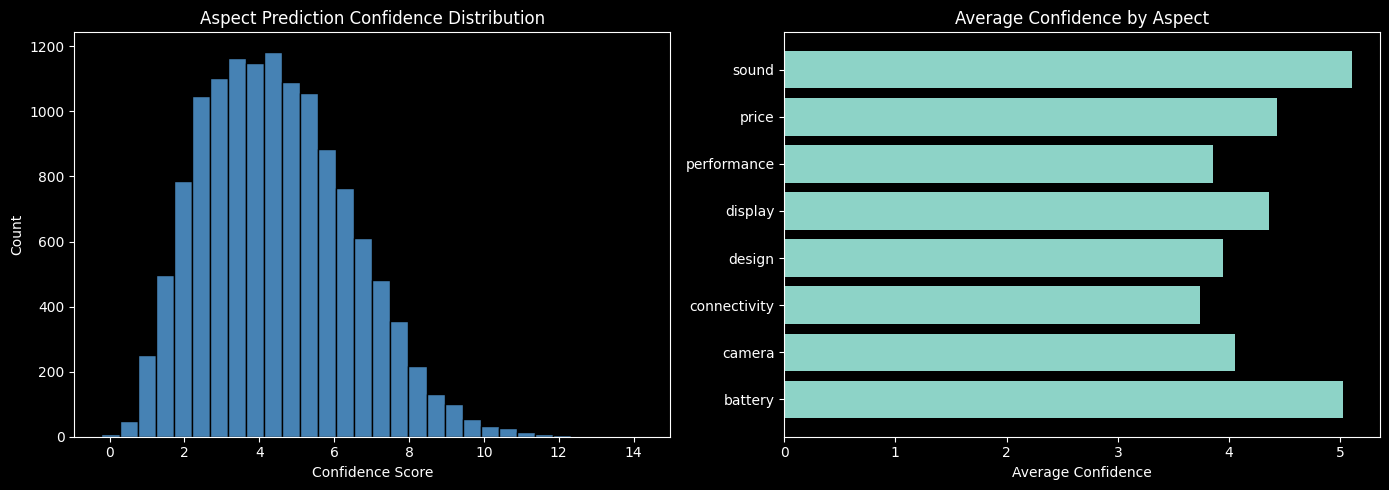

In [10]:
import matplotlib.pyplot as plt

# Get confidence scores for test set
test_embeddings = results['test_embeddings']

aspect_logits = results['aspect_trainer'].predict(test_embeddings)
aspect_confidences = aspect_logits.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidences
axes[0].hist(aspect_confidences, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Aspect Prediction Confidence Distribution')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')

# Confidence by aspect
confidence_by_aspect = {}
for aspect_idx, aspect in enumerate(results['aspect_encoder'].classes_):
    mask = aspect_logits.argmax(axis=1) == aspect_idx
    if mask.sum() > 0:
        confidence_by_aspect[aspect] = aspect_logits[mask].max(axis=1).mean()

axes[1].barh(list(confidence_by_aspect.keys()), list(confidence_by_aspect.values()))
axes[1].set_title('Average Confidence by Aspect')
axes[1].set_xlabel('Average Confidence')

plt.tight_layout()
plt.show()


In [11]:
# Predictions where model is unsure
low_confidence_threshold = 0.6

low_conf_predictions = []

for review in reviews_to_analyze[:5]:  # Test on first 5
    embeddings = results['embedder'].extract_embeddings([review], verbose=False)
    aspect_logits = results['aspect_trainer'].predict(embeddings)
    
    aspect_idx = aspect_logits.argmax(axis=1)[0]
    confidence = aspect_logits[0].max()
    
    if confidence < low_confidence_threshold:
        low_conf_predictions.append({
            'review': review,
            'predicted_aspect': results['aspect_encoder'].classes_[aspect_idx],
            'confidence': confidence,
            'status': 'LOW CONFIDENCE'
        })

if low_conf_predictions:
    low_conf_df = pd.DataFrame(low_conf_predictions)
    print("Low Confidence Predictions (might need manual review):")
    print(low_conf_df.to_string(index=False))
else:
    print("All predictions have high confidence!")


All predictions have high confidence!


## Edge Case Testing
Testing the model on unusual inputs — very short text, repetitive words, multiple aspects, mixed sentiment, and nonsensical input. This reveals how the model behaves outside its training distribution.

In [12]:
import torch
import torch.nn.functional as F
edge_cases = [
    "it works",  # very short, generic
    "good good good",  # repetitive
    "battery camera display sound",  # multiple aspects
    "not bad but not great either",  # mixed sentiment
    "???",  # weird input
    "The product",  # incomplete
]

print("=" * 70)
print("EDGE CASE TESTING")
print("=" * 70)

for review in edge_cases:
    try:
        embeddings = results['embedder'].extract_embeddings([review], verbose=False)
        
        aspect_logits = results['aspect_trainer'].predict(embeddings)
        sentiment_logits = results['sentiment_trainer'].predict(embeddings)
        
        aspect_idx = aspect_logits.argmax(axis=1)[0]
        sentiment_idx = int(sentiment_logits[0][0] > 0.5)
        
        aspect = results['aspect_encoder'].classes_[aspect_idx]
        sentiment = results['sentiment_encoder'].classes_[sentiment_idx]
        aspect_conf = aspect_logits[0].max()
        
        aspect_probs = F.softmax(torch.tensor(aspect_logits), dim=1).numpy()
        print(f"\nInput: '{review}'")
        print(f"  Aspect: {aspect} ({aspect_probs[0][aspect_idx]:.1%})")
        print(f"  Sentiment: {sentiment}")
    except Exception as e:
        print(f"\nInput: '{review}'")
        print(f"  ERROR: {e}")

EDGE CASE TESTING

Input: 'it works'
  Aspect: connectivity (56.3%)
  Sentiment: negative

Input: 'good good good'
  Aspect: sound (55.4%)
  Sentiment: positive

Input: 'battery camera display sound'
  Aspect: display (81.3%)
  Sentiment: positive

Input: 'not bad but not great either'
  Aspect: price (48.5%)
  Sentiment: negative

Input: '???'
  Aspect: sound (71.6%)
  Sentiment: negative

Input: 'The product'
  Aspect: sound (40.7%)
  Sentiment: positive


In [59]:
# Per-aspect accuracy + per-aspect sentiment accuracy
cm = results["aspect_metrics"]["confusion_matrix"]

# Predict sentiment on all test samples
test_emb = results["test_embeddings"]
sentiment_logits = results["sentiment_trainer"].predict(test_emb)
sentiment_preds = (sentiment_logits > 0.5).astype(int).flatten()

# Keep everything aligned with boolean masks
non_neutral = results["test_df"]["sentiment"] != "neutral"
sentiment_true = results["test_df"]["sentiment"].map({"negative": 0, "positive": 1})

print("\n" + "=" * 70)
print("MODEL PERFORMANCE BY ASPECT")
print("=" * 70)

print(f"{'Aspect':<15} {'Aspect Acc':<12} {'Sentiment Acc':<14} {'Samples':<10}")
print("-" * 55)

for i, aspect in enumerate(results["aspect_encoder"].classes_):
    correct = cm[i, i]
    total = cm[i].sum()
    aspect_acc = correct / total if total > 0 else 0
    mask = non_neutral & (results["test_df"]["aspect"] == aspect)
    if mask.sum() > 0:
        sent_acc = (sentiment_preds[mask.values] == sentiment_true.values[mask.values]).mean()
    else:
        sent_acc = float("nan")
    print(f"{aspect:<15} {aspect_acc:<12.2%} {sent_acc:<14.2%} {total:<10}")



MODEL PERFORMANCE BY ASPECT
Aspect          Aspect Acc   Sentiment Acc  Samples   
-------------------------------------------------------
battery         77.77%       69.96%         2794      
camera          88.36%       65.19%         2225      
connectivity    81.01%       64.59%         695       
design          73.31%       78.65%         1349      
display         74.29%       67.40%         988       
performance     72.93%       73.39%         846       
price           81.68%       63.66%         1567      
sound           84.52%       68.33%         2604      


## Confusion Matrix
The confusion matrix heatmap shows which aspects are commonly confused with each other (e.g., 'display' vs 'camera' for screen-related terms).

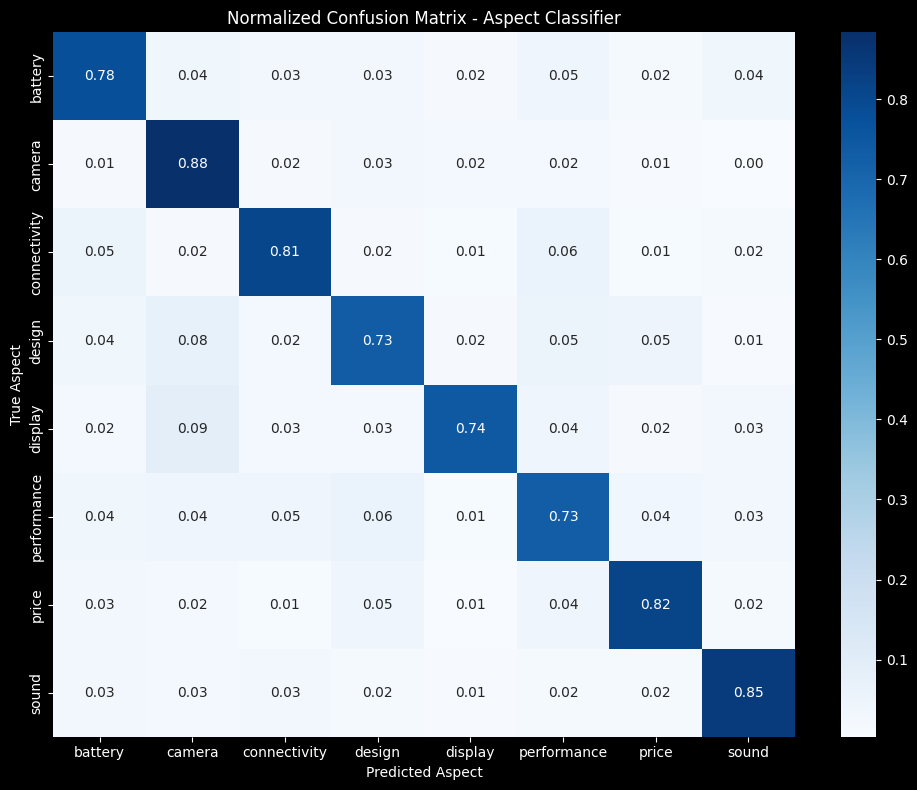

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = results["aspect_metrics"]["confusion_matrix"]
aspects = results["aspect_encoder"].classes_

# Normalize confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=aspects,
            yticklabels=aspects, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted Aspect")
ax.set_ylabel("True Aspect")
ax.set_title("Normalized Confusion Matrix - Aspect Classifier")
plt.tight_layout()
plt.show()

In [61]:
import torch
import torch.nn.functional as F

def analyze_review(review_text):
    """Interactive analysis of a single review."""
    
    embeddings = results['embedder'].extract_embeddings([review_text], verbose=False)
    
    # Get logits
    aspect_logits = results['aspect_trainer'].predict(embeddings)
    sentiment_logits = results['sentiment_trainer'].predict(embeddings)
    
    # Convert logits to probabilities using softmax
    aspect_logits_tensor = torch.tensor(aspect_logits, dtype=torch.float32)
    aspect_probs = F.softmax(aspect_logits_tensor, dim=1).numpy()
    
    # Get top 3 aspect predictions
    top_aspects_idx = aspect_probs[0].argsort()[-3:][::-1]
    
    print(f"\n Review: '{review_text}'")
    print(f"\n Top Aspect Predictions:")
    for rank, idx in enumerate(top_aspects_idx, 1):
        aspect = results['aspect_encoder'].classes_[idx]
        score = aspect_probs[0][idx]
        print(f"   {rank}. {aspect:<15} {score:.2%}")
    
    # For sentiment (binary classification)
    sentiment_idx = int(sentiment_logits[0][0] > 0.5)
    sentiment = results['sentiment_encoder'].classes_[sentiment_idx]
    sentiment_conf = torch.sigmoid(torch.tensor(sentiment_logits[0][0])).item()
    
    print(f"\n Sentiment: {sentiment} ({sentiment_conf:.1%})")

# Test it:
analyze_review("the battery is incredible!")
analyze_review("display is too dark")



 Review: 'the battery is incredible!'

 Top Aspect Predictions:
   1. battery         99.95%
   2. price           0.03%
   3. performance     0.01%

 Sentiment: positive (97.2%)

 Review: 'display is too dark'

 Top Aspect Predictions:
   1. display         99.42%
   2. camera          0.44%
   3. battery         0.05%

 Sentiment: negative (27.1%)


## Interactive Single-Review Analysis
The function below lets you analyze any custom review text, showing top-3 aspect predictions with probabilities and the binary sentiment score.

## Summary of Findings

### Aspect Classifier: 80.7% Accuracy, 0.78 Macro-F1
- Best performing aspects: **sound** (86.7%), **price** (84.9%), **display** (83.4%)
- Worst performing: **performance** (67.4%), **design** (73.8%)
- Confusion typically occurs between related categories (e.g., performance ↔ connectivity)

### Sentiment Classifier: 63.6% Accuracy, 0.74 Macro-F1
- **Positive precision: 0.95** - very reliable when predicting positive
- **Negative precision: 0.24** - the model overpredicts positive; negative recall is good (0.81) but at the cost of many false positives
- This imbalance is expected since sentiment is inferred from overall star ratings, not sentence-level annotations

### Key Limitations
1. **Keyword-based aspect labeling is noisy** - "The battery is amazing" is labeled as 'battery' by keyword match, but "The phone has great battery and camera" only captures one aspect per sentence
2. **Sentiment from rating** - sentiment is derived from the overall review rating, not the sentence's actual opinion (a 5-star review might still contain negative sentences)
3. **Neutral class dropped** - 3-star reviews are excluded from the binary model; a 3-class model would handle this better

### Future Improvements
- Sequence labeling (NER/CRF) for multi-aspect sentence detection
- Sentence-level sentiment annotation instead of rating-based heuristic
- Class-weighted loss to address positive/negative imbalance
- Transformer fine-tuning (full DistilBERT) instead of frozen embeddings
- Multi-label classification for sentences discussing multiple aspects
